### Homework 5

In [ ]:
# Load packages 
import us
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import numpy as np
import pyfixest as pf

In [ ]:
# Load Data from HCRIS
data_2009 = pd.read_csv('../Homework4/data/output/data-2009.csv')
data_2010 = pd.read_csv('../Homework4/data/output/data-2010.csv')
data_2011 = pd.read_csv('../Homework4/data/output/data-2011.csv')
data_2012 = pd.read_csv('../Homework4/data/output/data-2012.csv')
data_2013 = pd.read_csv('../Homework4/data/output/data-2013.csv')
data_2014 = pd.read_csv('../Homework4/data/output/data-2014.csv')
data_2015 = pd.read_csv('../Homework4/data/output/data-2015.csv')
data_2016 = pd.read_csv('../Homework4/data/output/data-2016.csv')
data_2017 = pd.read_csv('../Homework4/data/output/data-2017.csv')
data_2018 = pd.read_csv('../Homework4/data/output/data-2018.csv')

In [ ]:
# Combine data
data_2010["tot_uncomp_care_charges"] = data_2010["uncomp_care"]
data = pd.concat([data_2010, data_2011, data_2012, data_2013, data_2014, data_2015, data_2016, data_2017, data_2018], ignore_index=True)

In [ ]:
# Load KFF data
kff_final = pd.read_excel('raw_data.xlsx')
kff_final["expanded"] = kff_final["Adopted: 41 states (incl. DC)  Not Adopted: 10 states"] == "Adopted"
kff_final["year"] = pd.to_datetime(kff_final["Expansion Implementation Date"], errors="coerce").dt.year.astype("Int64")
kff_final = kff_final.rename(columns={"Location": "state"})
kff_final = kff_final.rename(columns={"year": "expansion_year"})

In [ ]:
# Clean States and merge 
data["state"] = data["state"].apply(
    lambda x: us.states.lookup(x).name if us.states.lookup(x) else x
)
data.loc[data["state"] == "DC", "state"] = "District of Columbia"
data = data[~data["state"].isin(["Puerto Rico", "Virgin Islands", "Guam", "Northern Mariana Islands"])]

merged = data.merge(kff_final, on="state", how="left")

# Question 1

In [18]:
# Uncomp_care variable 
merged["uncomp_care"] = (
    merged["tot_uncomp_care_charges"]
    - merged["tot_uncomp_care_partial_pmts"]
    + merged["bad_debt"]
)

merged.loc[
    merged[[
        "tot_uncomp_care_charges",
        "tot_uncomp_care_partial_pmts",
        "bad_debt"
    ]].isna().any(axis=1),
    "uncomp_care"
] = np.nan

In [19]:
merged["tot_uncomp_mills"] = merged["uncomp_care"]/1000000
question_1 = (
    merged.groupby("year", as_index=False)["tot_uncomp_mills"]
    .mean()
)
question_1 = question_1.round({"tot_uncomp_mills": 2}).rename(
    columns={
        "year": "Year",
        "tot_uncomp_mills": "Mean Uncompensated Care in Millions ($)"
    }
)
question_1

,Year,Mean Uncompensated Care in Millions ($)
0,2010,NaN
1,2011,34.66
2,2012,37.54
3,2013,39.43
4,2014,36.63
5,2015,33.37
6,2016,45.24
7,2017,41.14
8,2018,39.10


The amount of uncompensated care increased at a steady rate from 2011-2013 and then decreased in 2014 and 2015 following the ACA expansion. Then, uncompensated care increased dramatically in 2016 and decreased slightly afterwards.

## Question 2

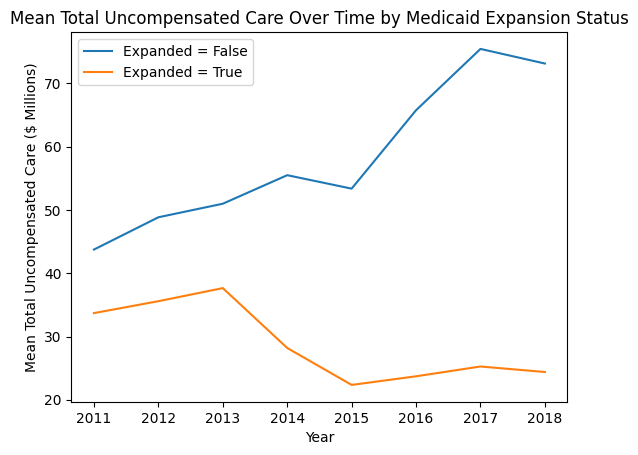

In [20]:
question_2 = merged[(merged["expansion_year"] == 2014) | (merged["expansion_year"].isna())].copy()
plot_2 = (
    question_2.groupby(["year", "expanded"], as_index=False)["tot_uncomp_mills"]
      .mean()
)

#plot_2["total_uncompensated_millions"] = plot_2["uncomp_care"] / 1000000

for status, group in plot_2.groupby("expanded"):
    plt.plot(group["year"], group["tot_uncomp_mills"], label=f"Expanded = {status}")

plt.xlabel("Year")
plt.ylabel("Mean Total Uncompensated Care ($ Millions)")
plt.title("Mean Total Uncompensated Care Over Time by Medicaid Expansion Status")
plt.legend()
plt.show()

The data suggests a possible treatment effect. It appears that uncompensated care increased in states that did not expand Medicaid and decreased in states that did expand after 2014.

## Question 3

In [21]:
question_3 = question_2[(question_2["year"] == 2012) | (question_2["year"] == 2015)].copy()
question_3["post"] = question_3["year"] >= 2015

In [22]:
dd_means = (
    question_3
    .groupby(["expanded", "post"], as_index=False)
    .agg(mean_uncomp_care=("uncomp_care", lambda x: x.mean() / 1_000_000))
)

dd_means["expanded"] = dd_means["expanded"].map({True: "Expanded", False: "Not Expanded"})
dd_means["post"] = dd_means["post"].map({True: "2015 (Post)", False: "2012 (Pre)"})

table_3 = (
    dd_means
    .pivot(index="expanded", columns="post", values="mean_uncomp_care")
    .reindex(index=["Expanded", "Not Expanded"], columns=["2012 (Pre)", "2015 (Post)"])
    .round(2)
)

table_3.index.name = ""
table_3.columns.name = ""

table_3

,2012 (Pre),2015 (Post)
,,
Expanded,35.58,22.35
Not Expanded,48.85,53.38


## Question 4 

The average uncompensated care increased in the states that did not expand Medicaid and decreased in the States that did expand, on average. This makes sense as the population that received insurance as a result of the ACA Medicaid expansion would have been contributing to the uncompensated care. Now, they have insurance that pays the hospital, decreasing the uncompensated care. However, the States that did not expand had the same population still receiving uncompensated care three years later.

## Question 5

In [23]:
dd_dat_for_reg = question_2.copy()
dd_dat_for_reg["post"] = dd_dat_for_reg["year"] >= 2014

dd_dat_for_reg["expanded"] = dd_dat_for_reg["expanded"].astype(int)
dd_dat_for_reg["post"] = dd_dat_for_reg["post"].astype(int)

dd_est = smf.ols("tot_uncomp_mills ~ expanded + post + expanded:post", data=dd_dat_for_reg).fit()

results_table = pd.DataFrame({
    "Coefficient": dd_est.params,
    "Std. Error": dd_est.bse,
    "t-stat": dd_est.tvalues,
    "p-value": dd_est.pvalues
}).round(3)

results_table.index = ["Intercept", "Expansion", "Post", "Expansion × Post"]

results_table

,Coefficient,Std. Error,t-stat,p-value
Intercept,48.159,2.129,22.617,0.0
Expansion,-12.481,2.679,-4.659,0.0
Post,15.718,2.699,5.825,0.0
Expansion × Post,-26.608,3.405,-7.814,0.0


## Question 6

In [24]:
question_6 = dd_dat_for_reg.dropna(
    subset=["tot_uncomp_mills", "expanded", "post", "provider_number", "year", "state"]
).copy()
m_dd = smf.ols("tot_uncomp_mills ~ post + expanded + expanded:post", data=question_6).fit()
m_twfe = smf.ols(
    "tot_uncomp_mills ~ expanded:post + C(provider_number) + C(year)",
    data=question_6
).fit(cov_type="cluster", cov_kwds={"groups": question_6["state"]})

table_6 = pd.DataFrame({
    "Coefficient": [m_twfe.params["expanded:post"]],
    "Std. Error": [m_twfe.bse["expanded:post"]],
    "t-stat": [m_twfe.tvalues["expanded:post"]],
    "p-value": [m_twfe.pvalues["expanded:post"]],
    "Num. Obs": [int(m_twfe.nobs)],
}, index=["Expansion × Post"]).round(3)

table_6

,Coefficient,Std. Error,t-stat,p-value,Num. Obs
Expansion × Post,-30.264,6.227,-4.86,0.0,14917


The difference in differences treatment effect becomes more negative when adding in hospital and year fixed effects. This means that Medicaid expansion is associated with even greater reductions in uncompensated care when controlling for differences in hospitals and shocks for common years. 

## Question 7

In [38]:
question_7 = merged.copy()
question_7["treat_post_all"] = (
    (question_7["expansion_year"].notna()) &
    (question_7["year"] >= question_7["expansion_year"])
).astype(int)

In [39]:
question_7_2 = question_7.dropna(
    subset=["tot_uncomp_mills", "treat_post_all", "provider_number", "year", "state"]
).copy()

question_7_2["provider_number"] = question_7_2["provider_number"].astype(str)

m_twfe_7 = pf.feols(
    "tot_uncomp_mills ~ treat_post_all | provider_number + year",
    data=question_7_2,
    vcov={"CRV1": "state"}
)

tidy_7 = m_twfe_7.tidy().reset_index()

table_7 = tidy_7.loc[tidy_7["Coefficient"] == "treat_post_all", [
    "Coefficient", "Estimate", "Std. Error", "t value", "Pr(>|t|)"
]].copy()

table_7 = table_7.rename(columns={
    "Coefficient": "Term",
    "Estimate": "Coefficient",
    "t value": "t-stat",
    "Pr(>|t|)": "p-value"
}).round(3)

table_7

/local/5261/econ470001/a0/conda-env/lib/python3.13/site-packages/pyfixest/estimation/model_matrix_fixest_.py:215: UserWarning: 464 singleton fixed effect(s) detected. These observations are dropped from the model.
  warnings.warn(


,Term,Coefficient,Std. Error,t-stat,p-value
0,treat_post_all,-23.302,4.545,-5.127,0.0


The difference in difference treatment effect decreased (became less negative). This is likely due to states that expanded in 2015, as these would still be considered as treated but they would not see the cost savings yet (in terms of uncompensated care). 

## Question 8

In [30]:
# Clean types
question_8 = question_2.copy()
question_8["expand2014"] = question_8["expansion_year"].eq(2014).fillna(False).astype(int)
question_8["tot_uncomp_mills"] = pd.to_numeric(question_8["tot_uncomp_mills"], errors="coerce")
question_8["provider_number"] = question_8["provider_number"].astype(str)
question_8["year"] = pd.to_numeric(question_8["year"], errors="coerce")

question_8 = question_8.dropna(subset=["tot_uncomp_mills", "provider_number", "year", "state"])

mod_event = pf.feols(
    "tot_uncomp_mills ~ i(year, expand2014, ref=2013) | provider_number + year",
    data=question_8,
    vcov={"CRV1": "state"}
)

/local/5261/econ470001/a0/conda-env/lib/python3.13/site-packages/pyfixest/estimation/model_matrix_fixest_.py:215: UserWarning: 361 singleton fixed effect(s) detected. These observations are dropped from the model.
  warnings.warn(


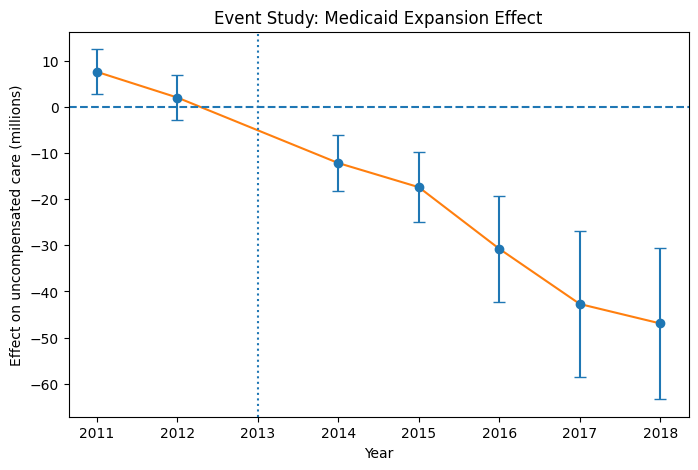

In [31]:
tidy = mod_event.tidy().copy()
tidy = tidy.reset_index()

es = tidy[tidy["Coefficient"].astype(str).str.contains(r"C\(year", na=False)].copy()
es["plot_year"] = es["Coefficient"].str.extract(r"\[(\d{4})\]").astype(int)
es = es.sort_values("plot_year")
es["ci_low"] = es["Estimate"] - 1.96 * es["Std. Error"]
es["ci_high"] = es["Estimate"] + 1.96 * es["Std. Error"]

# Plot
plt.figure(figsize=(8,5))
plt.errorbar(
    es["plot_year"],
    es["Estimate"],
    yerr=1.96 * es["Std. Error"],
    fmt="o",
    capsize=4
)
plt.plot(es["plot_year"], es["Estimate"])
plt.axhline(0, linestyle="--")
plt.axvline(2013, linestyle=":")
plt.xticks([2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018])
plt.xlabel("Year")
plt.ylabel("Effect on uncompensated care (millions)")
plt.title("Event Study: Medicaid Expansion Effect")
plt.show()

## Question 9

In [32]:
# time to treat = ifelse(expand)ever == TRUE, year - expand_year, -1) 
question_9 = merged.copy()
question_9 = question_9.dropna(
    subset=["tot_uncomp_mills", "expanded", "provider_number", "year", "state"]
).copy()

question_9["time_to_treat"] = np.where(
    question_9["expanded"].astype(bool),
    question_9["year"] - question_9["expansion_year"],
    -1
)

question_9["time_to_treat"] = question_9["time_to_treat"].clip(lower=-4, upper=4)

mod_event_9 = smf.ols(
    "tot_uncomp_mills ~ C(time_to_treat, Treatment(reference=-1)):expanded + C(provider_number) + C(year)",
    data=question_9
).fit(cov_type="cluster", cov_kwds={"groups": question_9["state"]})

tidy_9 = mod_event_9.summary2().tables[1].reset_index()
tidy_9 = tidy_9.rename(columns={"index": "Coefficient"})

print(tidy_9[["Coefficient", "Coef.", "Std.Err."]])

                                            Coefficient       Coef.   Std.Err.
0                                             Intercept   94.157903   6.702162
1                           C(provider_number)[T.10005]  -74.837514   2.734088
2                           C(provider_number)[T.10006]  -58.942262   2.934794
3                           C(provider_number)[T.10007] -103.809213   3.913620
4                           C(provider_number)[T.10010]  -91.217106   6.702162
...                                                 ...         ...        ...
3892  C(time_to_treat, Treatment(reference=-1))[T.0....  -15.493063   6.048886
3893  C(time_to_treat, Treatment(reference=-1))[T.1....   -2.185362  17.388649
3894  C(time_to_treat, Treatment(reference=-1))[T.2....  -42.142482  14.497300
3895  C(time_to_treat, Treatment(reference=-1))[T.3....  -40.613620   8.957400
3896  C(time_to_treat, Treatment(reference=-1))[T.4....  -36.342864  10.237746

[3897 rows x 3 columns]


/home/segitli/econ470/a0/pyenv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3896, but rank is 15
  warnings.warn('covariance of constraints does not have full '


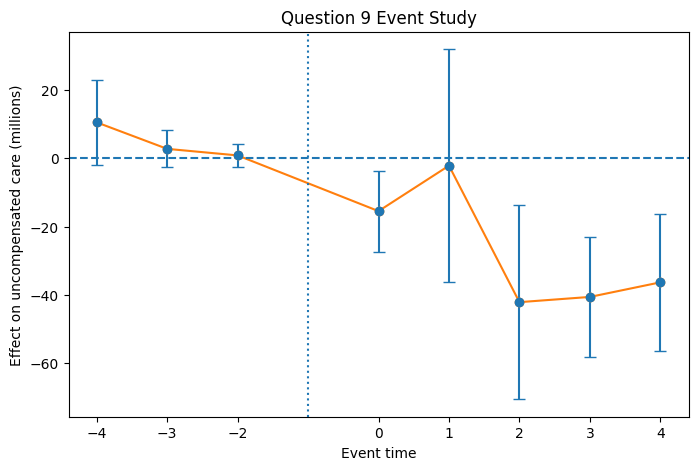

In [33]:
# keep only the interaction terms, which are the event-study effects
plot_df = tidy_9[
    tidy_9["Coefficient"].str.contains(r"expanded\[True\]", regex=True, na=False)
].copy()

plot_df["event_time"] = (
    plot_df["Coefficient"]
    .str.extract(r"\[T\.(-?\d+)\.0\]:expanded\[True\]", expand=False)
    .astype(int)
)
plot_df = plot_df.sort_values("event_time")
plot_df["ci_low"] = plot_df["Coef."] - 1.96 * plot_df["Std.Err."]
plot_df["ci_high"] = plot_df["Coef."] + 1.96 * plot_df["Std.Err."]

plt.figure(figsize=(8,5))
plt.errorbar(
    plot_df["event_time"],
    plot_df["Coef."],
    yerr=1.96 * plot_df["Std.Err."],
    fmt="o",
    capsize=4
)
plt.plot(plot_df["event_time"], plot_df["Coef."], marker="o")
plt.axhline(0, linestyle="--")
plt.axvline(-1, linestyle=":")
plt.xlabel("Event time")
plt.ylabel("Effect on uncompensated care (millions)")
plt.title("Question 9 Event Study")
plt.xticks(sorted(plot_df["event_time"].unique()))
plt.show()

## Question 10

Questions 5-9 all support the idea that Medicaid expansion decreases uncompensated care compared to states that did not expand. Question 5 shows a large decrease in uncompensated care for expanded Medicaid states after 2014. Question 6 shows an even greater impact when including hospital and year fixed effects. Question 7 shows that this trend is consistent even when considering later expanders. Question 8 shows a continual decrease in uncompensated care each year for expander states. Question 9 further supports this even when considering later expanders. The event study graphs support the parellel trends assumption because the esimates in the pre-period are close to 0, even if they show a slight decline leading up to the reference period. One limitation in the staggered expansions is that the event time for 4 years after has a much smaller sample that say 1 year after. This is because in order to be included in the 4 year post-period (2018), the only states included would have had to expand in 2014. 